# ML Pipeline — Tesla Deliveries & Price Data (2015–2025)

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing   import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV
import joblib
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA


## Load Dataset

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
# The dataset is Not sorted
df = df.sort_values(by = ['Year', 'Month']).reset_index(drop=True)
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2015,1,Middle East,Model Y,10348,10835,85599.95,82,488,757.47,Estimated (Region),5991
1,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390
2,2015,1,Europe,Model Y,10835,11723,62939.81,120,718,1166.93,Official (Quarter),12301
3,2015,1,North America,Model X,8122,8343,62838.32,75,423,515.34,Official (Quarter),9297
4,2015,1,Middle East,Model S,13902,15423,94629.02,75,445,927.96,Official (Quarter),8666


## Data Details

In [4]:
print(f"Shape: {df.shape}")
df.info()

Shape: (2640, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [5]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicated Rows:", df.duplicated().sum())

### NO MISSING VALUE IF THERE IN THE DATAFRAME ###

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicated Rows: 0


## Identify Column Types

In [6]:
TARGET = 'Estimated_Deliveries'
Num_col = ['Year', 'Month', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
            'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
Cat_col = ['Region', 'Model', 'Source_Type']

print(f"Numerical   : {Num_col}")
print(f"Categorical : {Cat_col}")
print(f"Target      : {TARGET}")

Numerical   : ['Year', 'Month', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
Categorical : ['Region', 'Model', 'Source_Type']
Target      : Estimated_Deliveries


## 1. EDA — Univariate Analysis

### Numerical

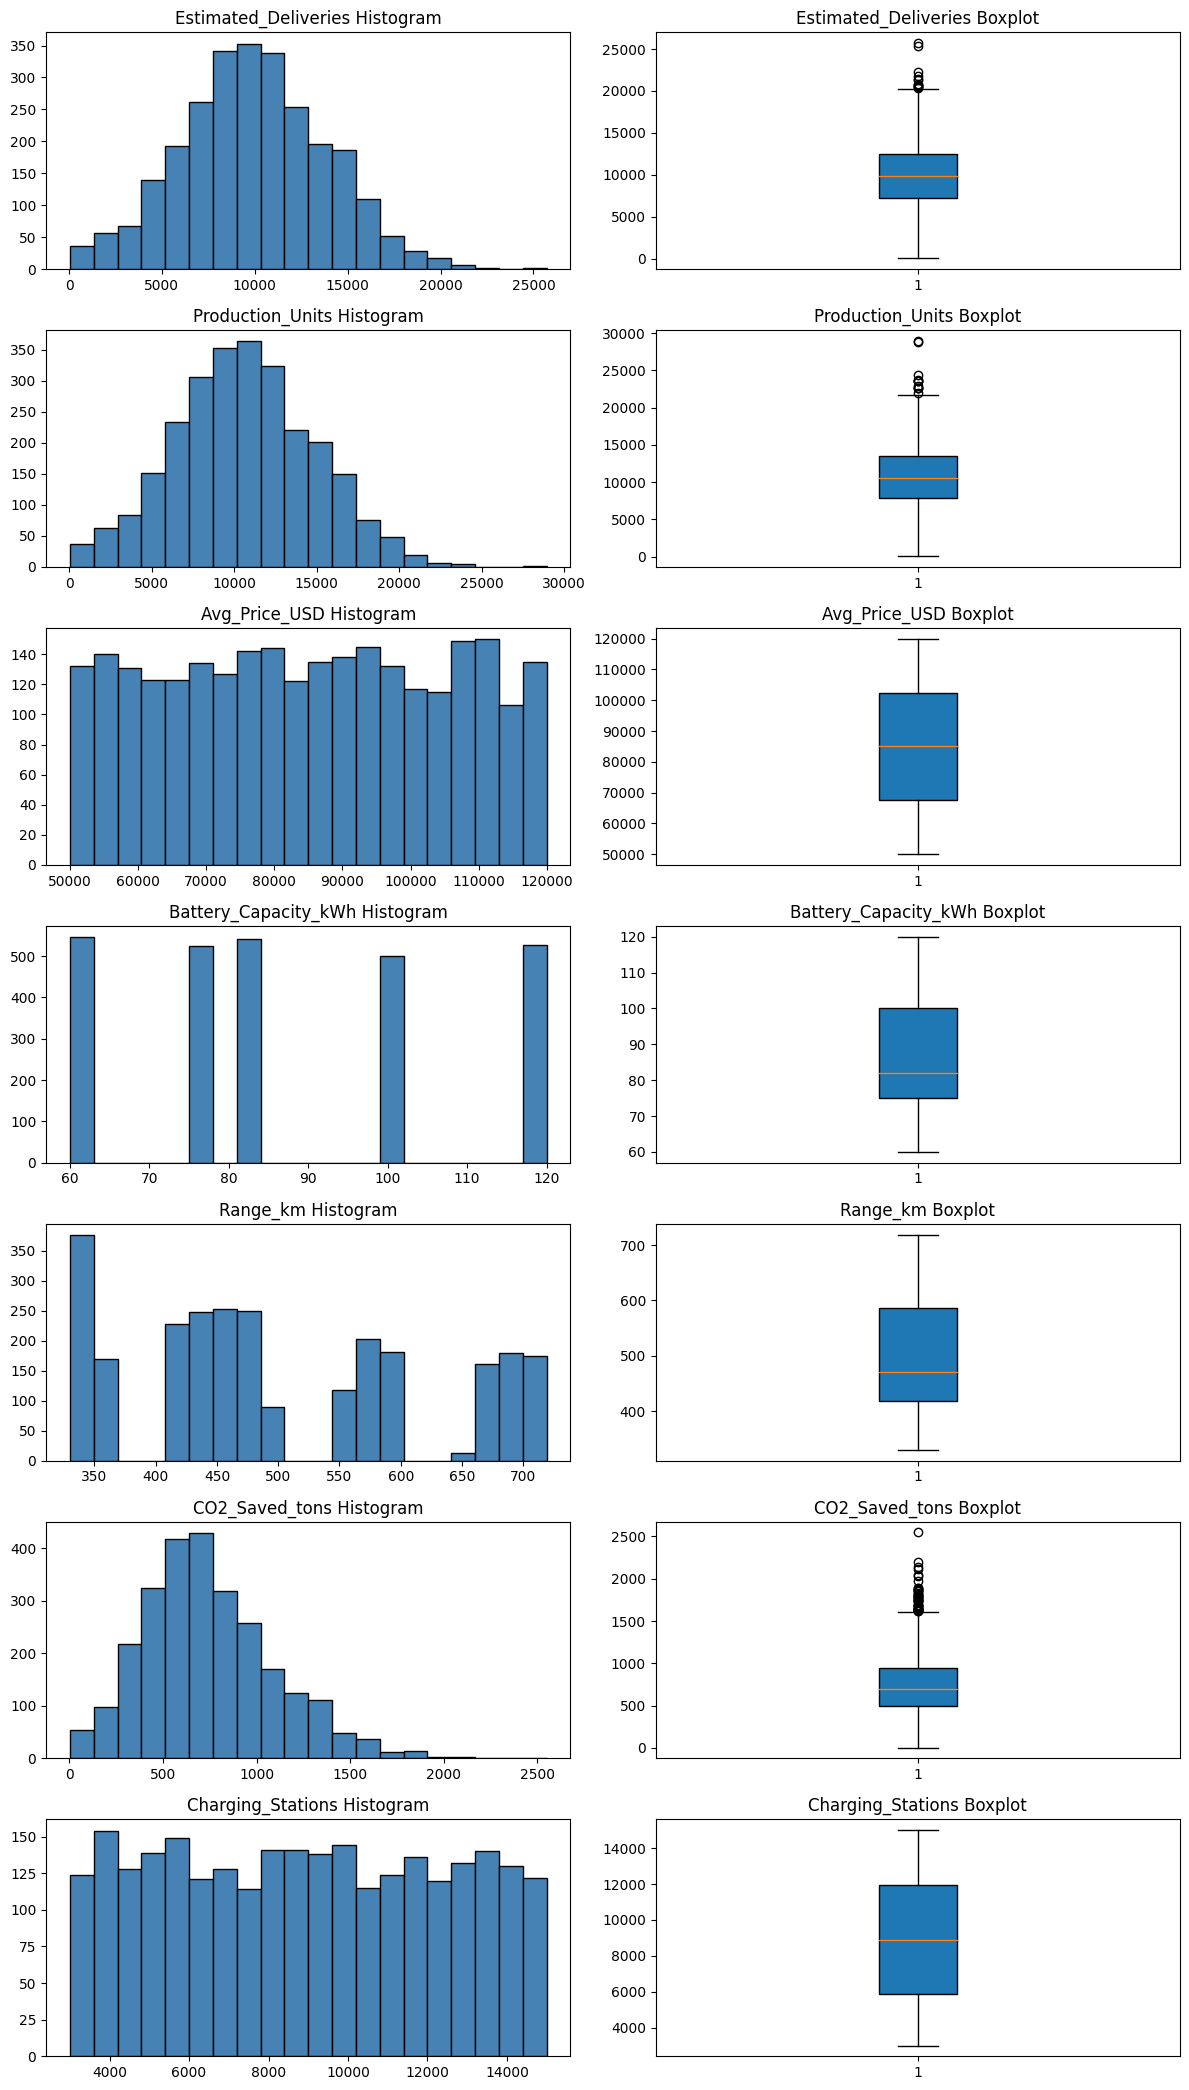

In [7]:
plot_num = [i for i in Num_col if i not in ('Year', 'Month')]
fig, axes = plt.subplots(len(plot_num), 2, figsize=(12, len(plot_num) * 3))

for i, col in enumerate(plot_num):
    axes[i, 0].hist(df[col], bins=20, color='steelblue', edgecolor='black')
    axes[i, 0].set_title(f'{col} Histogram')

    axes[i, 1].boxplot(df[col], patch_artist=True)
    axes[i, 1].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

### Categorical

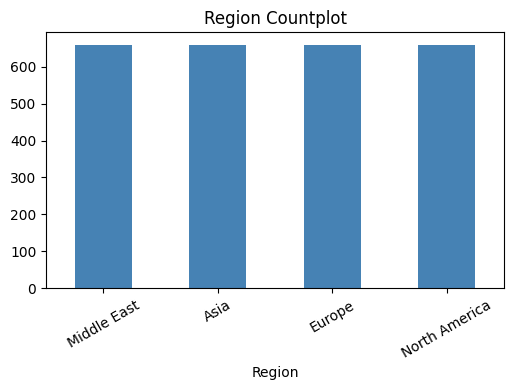

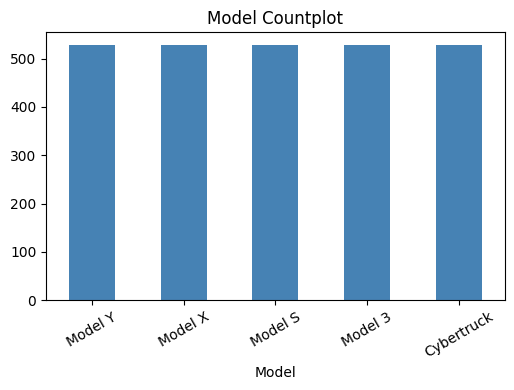

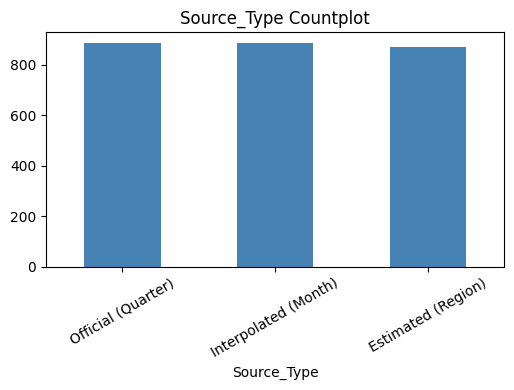

In [8]:
for col in Cat_col:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    df[col].value_counts().plot(kind='bar', color='steelblue')
    plt.title(f'{col} Countplot')
    plt.xticks(rotation=30)
    
    plt.tight_layout()
    plt.show()

### Yearly Deliveries Trend

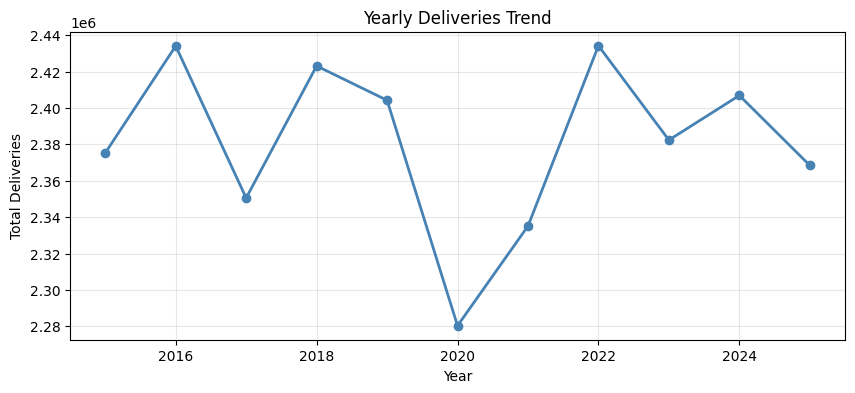

In [9]:
yearly = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10, 4))
plt.plot(yearly.index, yearly.values, marker='o', color='steelblue', lw=2)
plt.title('Yearly Deliveries Trend')
plt.xlabel('Year')
plt.ylabel('Total Deliveries')
plt.grid(alpha=0.3)
plt.show()

# 2. Outlier Detection & Treatment

### IQR 

In [10]:
df_clean = df.copy()
plot_num.remove(TARGET)

for col in plot_num:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f"{col}: {outliers} outliers")

    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

Production_Units: 12 outliers
Avg_Price_USD: 0 outliers
Battery_Capacity_kWh: 0 outliers
Range_km: 0 outliers
CO2_Saved_tons: 45 outliers
Charging_Stations: 0 outliers


# 3. Feature Engineering

In [11]:
def Feature_Eng(df_clean):
    df_feat = df_clean.copy()

    df_feat['price_per_km'] = df_feat['Avg_Price_USD'] / df_feat['Range_km']
    df_feat['km_per_kWh'] = df_feat['Range_km'] / df_feat['Battery_Capacity_kWh']
    df_feat['Co2_per_unit'] = df_feat['CO2_Saved_tons'] / df_feat['Range_km']
    return df_feat

df_feat = Feature_Eng(df_clean)
df_feat[['price_per_km','km_per_kWh','Co2_per_unit']].head()

,price_per_km,km_per_kWh,Co2_per_unit
0,175.409734,5.951220,1.552193
1,162.303324,5.666667,1.866912
2,87.659903,5.983333,1.625251
3,148.553948,5.640000,1.218298
4,212.649483,5.933333,2.085303


# 4. Categorical Encoding

### Ordinal Encoder

In [12]:
from sklearn.preprocessing import OrdinalEncoder

ordin = OrdinalEncoder(categories= [[60, 75, 82, 100, 120]])
df_feat['Battery_Encode'] = ordin.fit_transform(df_feat[['Battery_Capacity_kWh']])

print(df_feat[['Battery_Encode','Battery_Capacity_kWh']].drop_duplicates())
df_feat = df_feat.drop(columns = ['Battery_Capacity_kWh'])

    Battery_Encode  Battery_Capacity_kWh
0              2.0                    82
1              0.0                    60
2              4.0                   120
3              1.0                    75
18             3.0                   100


### OneHot Encoder

In [13]:
df_feat = pd.get_dummies(df_feat, columns = Cat_col, drop_first=True)
df_feat.head()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Range_km,CO2_Saved_tons,Charging_Stations,price_per_km,km_per_kWh,...,Battery_Encode,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2015,1,10348,10835.0,85599.95,488,757.47,5991,175.409734,5.951220,...,2.0,False,True,False,False,False,False,True,False,False
1,2015,1,12446,13885.0,55183.13,340,634.75,4390,162.303324,5.666667,...,0.0,False,False,False,False,False,False,True,False,True
2,2015,1,10835,11723.0,62939.81,718,1166.93,12301,87.659903,5.983333,...,4.0,True,False,False,False,False,False,True,False,True
3,2015,1,8122,8343.0,62838.32,423,515.34,9297,148.553948,5.640000,...,1.0,False,False,True,False,False,True,False,False,True
4,2015,1,13902,15423.0,94629.02,445,927.96,8666,212.649483,5.933333,...,1.0,False,True,False,False,True,False,False,False,True


# 5. Model Training and CV with pipeline

In [14]:
plot_num.extend(['price_per_km','km_per_kWh','Co2_per_unit'])
plot_num.remove('Battery_Capacity_kWh')

data_processing = ColumnTransformer(transformers = [
    ('Ord', OrdinalEncoder(categories = [[60, 75, 82, 100, 120]]), ['Battery_Capacity_kWh']),
    ('Category', OneHotEncoder(drop='first', sparse_output=False), Cat_col),
    ('Scale', StandardScaler(), plot_num)])

Linear_Reg_pl = Pipeline([('Data', data_processing), ('model', LinearRegression())])
Lasso_Reg_pl = Pipeline([('Data', data_processing), ('model', Lasso(alpha = 1.0))])
Ridge_Reg_pl = Pipeline([('Data', data_processing), ('model', Ridge(alpha = 1.0))])

pipe_all = {"Linear": Linear_Reg_pl, "Lasso": Lasso_Reg_pl, "Ridge":Ridge_Reg_pl}

In [15]:
X = Feature_Eng(df_clean.drop(columns = TARGET))
y = df_clean[TARGET]

## Cross Validation

### K-Fold CV (K=5)

In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, pl in pipe_all.items():
    scr = cross_val_score(pl, X, y, cv=kf, scoring='r2')
    print(name, "R2: ",scr.mean().round(5))

Linear R2:  0.9946
Lasso R2:  0.99462
Ridge R2:  0.99462


### TimeSeriesSplit (K=5)

In [17]:
tscv = TimeSeriesSplit(n_splits=5)

for name, pl in pipe_all.items():
    scr = cross_val_score(pl, X, y, cv=tscv, scoring='r2')
    print(name, "R2: ",scr.mean().round(5))

Linear R2:  0.9951
Lasso R2:  0.99514
Ridge R2:  0.99512


### Train/Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Train: (2112, 14)  Test: (528, 14)


# 6. Hyperparameter Tuning

In [19]:
param_grid = {'model__alpha': [0.001, 0.01, 0.1, 1.0, 10, 100]}

lasso_tune = GridSearchCV(Lasso_Reg_pl, param_grid, cv=tscv, scoring='r2')
lasso_tune.fit(X_train, y_train)
print("Best alpha in Lasso: ",lasso_tune.best_params_)
print("Best R2 in Lasso: ",lasso_tune.best_score_.round(5))

ridge_tune = GridSearchCV(Ridge_Reg_pl, param_grid, cv=tscv, scoring='r2')
ridge_tune.fit(X_train, y_train)
print("Best alpha in Rigid: ",ridge_tune.best_params_)
print("Best R2 in Rigid: ",ridge_tune.best_score_.round(5))

Best alpha in Lasso:  {'model__alpha': 10}
Best R2 in Lasso:  0.99446
Best alpha in Rigid:  {'model__alpha': 1.0}
Best R2 in Rigid:  0.99437


# 7. Evaluation Metrics

In [20]:
for name, pl in pipe_all.items():
    model = pl
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("Name: ",name,"\n RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)), "\n MAE: ", mean_absolute_error(y_test, y_pred), 
          "\n R2:  ",r2_score(y_test, y_pred),"\n")
    
### Lasso Model is Better    

Name:  Linear 
 RMSE: 177.65721651975502 
 MAE:  141.07498955159556 
 R2:   0.9976541307754976 

Name:  Lasso 
 RMSE: 177.1291585326169 
 MAE:  140.05973838021367 
 R2:   0.9976680555009136 

Name:  Ridge 
 RMSE: 179.46376640088016 
 MAE:  142.78597762235157 
 R2:   0.997606179140848 



## Save Model

In [21]:
import joblib
joblib.dump(Lasso_Reg_pl, "Lasso.joblib")

['Lasso.joblib']

# 8. ARIMA Forecasting (Time Series Analysis)

### ADF Test — Stationarity Check

In [22]:
ts = df_clean.groupby(['Year', 'Month'])['Estimated_Deliveries'].sum().reset_index()
ts['Full_date'] = pd.to_datetime(ts[['Year','Month']].assign(day = 1))
ts = ts.set_index('Full_date')

score_adf = adfuller(ts[TARGET])
print("ADF: ", score_adf[0])
print("p-value: ", score_adf[1].round(2))

# It is stationary

ADF:  -8.880990349502865
p-value:  0.0


### ACF & PACF

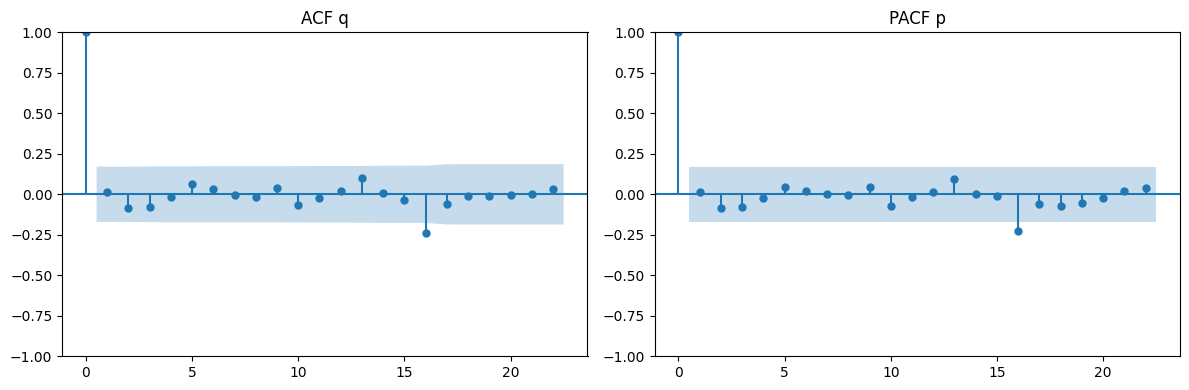

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf (ts[TARGET], ax=ax[0])
plot_pacf(ts[TARGET], ax=ax[1], method='ywm')
ax[0].set_title('ACF q')
ax[1].set_title('PACF p')
plt.tight_layout()
plt.show()

## ARIMA Tuning

In [24]:
X_train_ts = ts[TARGET].iloc[:-15]
X_test_ts  = ts[TARGET].iloc[-15:]

best_aic, best_order = np.inf, (1,1,1)

for p in range(4):
    for d in [0,1]:
        for q in range(4):
            try:
                m = ARIMA(X_train_ts, order=(p,d,q)).fit()
                if m.aic < best_aic:
                    best_aic, best_order = m.aic, (p,d,q)
            except:
                continue

print(f"Best ARIMA: {best_order}  AIC={best_aic:.2f}")

C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information 

C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information 

C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum 

Best ARIMA: (1, 0, 0)  AIC=2622.19


C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# Best Model and Plot

C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


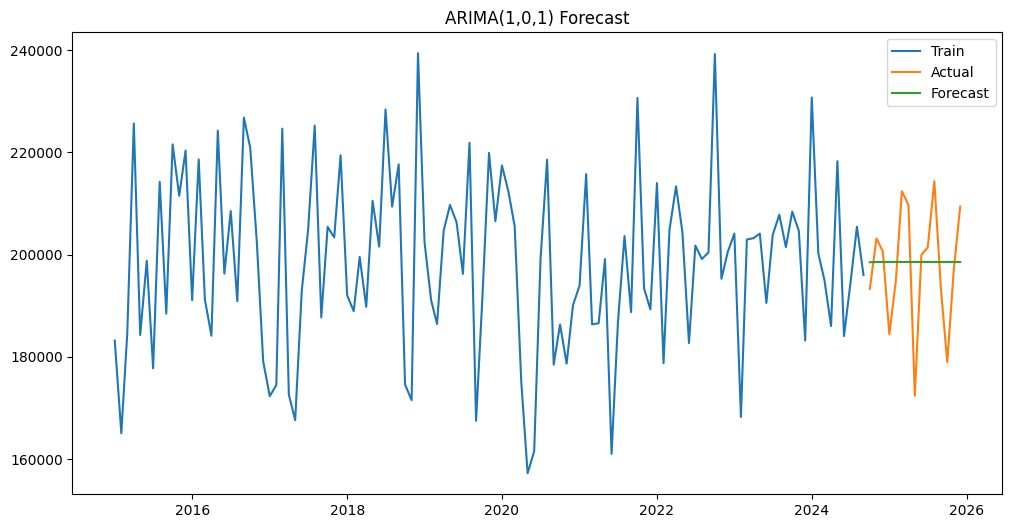

In [25]:
model = ARIMA(X_train_ts, order=best_order).fit()
y_pred = model.forecast(steps=len(X_test_ts))

plt.figure(figsize=(12,6))
plt.plot(X_train_ts.index, X_train_ts, label='Train')
plt.plot(X_test_ts.index, X_test_ts, label='Actual')
plt.plot(X_test_ts.index, y_pred, label='Forecast')

plt.title('ARIMA(1,0,1) Forecast')
plt.legend()
plt.show()
# plt.show()

In [29]:
print("MAPE: ", mean_absolute_percentage_error(X_test_ts, y_pred))
print("MAE:  ", mean_absolute_error(X_test_ts, y_pred))
print("RMSE: ", np.sqrt(mean_squared_error(X_test_ts, y_pred)))

MAPE:  0.04764585493006603
MAE:   9183.1915517594
RMSE:  11704.394497807203


In [27]:
# >>>>>>>> SUMMARY <<<<<<<<

## 1. ARIMA MODEL compare to Regression model is not performing well
##  - It is not performing well Might be because single feature 'Estimated_Deliveries'
##  - Regression Model is comparitively much much better

## >>> About Regression Model <<<
##  In the Regression model Lasso is working better      (RMSE: 177.1291   R2: 0.9976)
##  The Linear Regression is working fine too 2nd best   (RMSE: 177.6572   R2: 0.9976)